<a href="https://colab.research.google.com/github/jcmachicao/cur_MMAI__multimodal/blob/main/cur_IAMM___analisis_sonidos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow tensorflow-hub librosa numpy

In [9]:
import os
import numpy as np
import tensorflow as np_tf
import tensorflow_hub as hub
import librosa

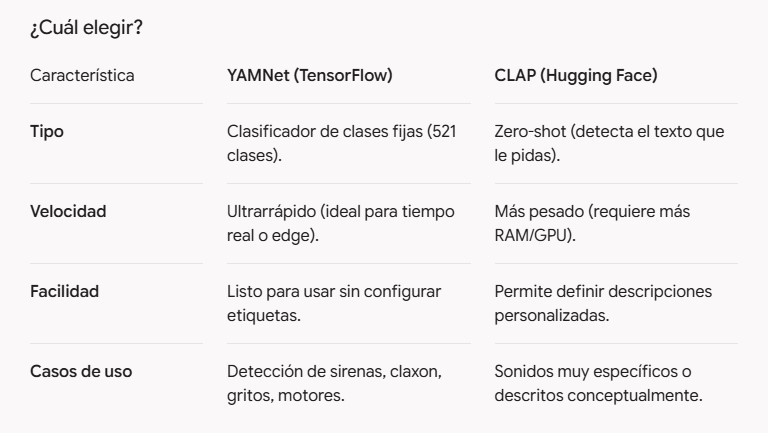

In [3]:
# 1. Cargar el modelo preentrenado de YAMNet desde TensorFlow Hub
model = hub.load('https://tfhub.dev/google/yamnet/1')

# Cargar las etiquetas del modelo (los nombres de las 521 clases)
class_map_path = model.class_map_path().numpy().decode('utf-8')
class_names = [line.strip().split(',')[1] for line in open(class_map_path).readlines()[1:]]

In [4]:
def analizar_audio(ruta_archivo):
    # 2. Cargar el audio corto y re-muestrear a 16kHz (frecuencia requerida por YAMNet)
    audio_data, sr = librosa.load(ruta_archivo, sr=16000, mono=True)

    # 3. Ejecutar la inferencia con el modelo
    scores, embeddings, spectrogram = model(audio_data)

    # Promediar las probabilidades a lo largo del tiempo del audio
    mean_scores = np.mean(scores, axis=0)

    # 4. Obtener las N clases con mayor probabilidad
    top_n = 5
    top_indices = np.argsort(mean_scores)[::-1][:top_n]

    print(f"\nResultados para: {ruta_archivo}")
    print("-" * 40)
    for i in top_indices:
        probabilidad = mean_scores[i] * 100
        etiqueta = class_names[i]
        print(f"{etiqueta}: {probabilidad:.2f}%")

In [10]:
ruta = "drive/My Drive/00 2026_all/2026 Lab/"
os.listdir(ruta)

['data_papa_1997_2021.xlsx',
 'cur_IAPP____RL_papa_optimizacion_venta.ipynb',
 'ruido_vaso.m4a']

In [11]:
analizar_audio(ruta + "ruido_vaso.m4a")

/tmp/ipykernel_2450/2401075932.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sr = librosa.load(ruta_archivo, sr=16000, mono=True)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Resultados para: drive/My Drive/00 2026_all/2026 Lab/ruido_vaso.m4a
----------------------------------------
/t/dd00125: 13.94%
/m/0l14md: 11.20%
/m/04rlf: 9.32%
/m/04szw: 8.99%
/m/0chx_: 7.98%


In [12]:
import numpy as np
import tensorflow_hub as hub

# Cargar modelo
model = hub.load('https://tfhub.dev/google/yamnet/1')

# --- CORRECCIÓN AQUÍ ---
# Extraer la columna [2] (display_name) en lugar de la [1] (mid)
class_map_path = model.class_map_path().numpy().decode('utf-8')
class_names = [line.strip().split(',')[2] for line in open(class_map_path).readlines()[1:]]
# ------------------------

# Al hacer la inferencia y buscar class_names[i],
# imprimirá "Percussion", "Inside, small room", etc., en lugar de /t/...

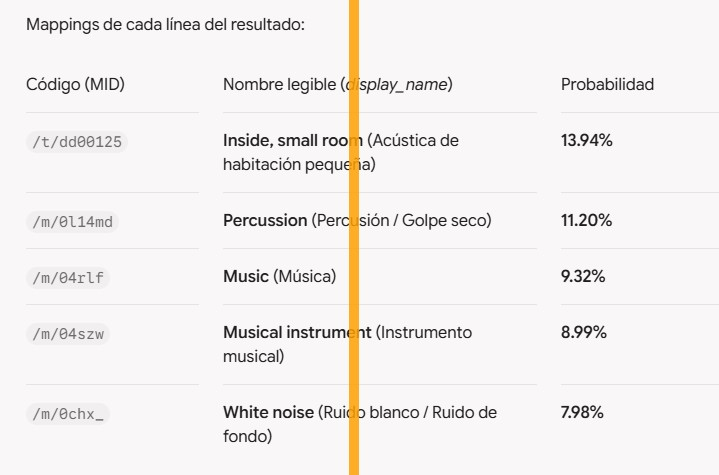